# Expert Systems

## 📚 Learning Objectives

By completing this notebook, you will:
- Design rule-based expert systems
- Implement simple inference engines

## 🔗 Where this fits

**Builds on:** Unit 1, lesson 10 "Knowledge Representation and Reasoning" — facts and rules become a working inference engine.

**Used later in:** Course 02 (AIAT 112) — Unit 2, where forward and backward chaining are implemented in full.

---


## 🎯 The program that out-prescribed the specialists — and was never used

**MYCIN** was built at Stanford in the 1970s: about 600 rules for diagnosing
bacterial infections of the blood and the meninges, and recommending
antibiotics. In **1979** *JAMA* published a blinded evaluation (Yu et al.,
*Antimicrobial Selection by a Computer*). Eight independent infectious-disease
experts, who did not know which recommendations came from the machine, rated the
therapy chosen for ten real meningitis cases. **MYCIN's recommendations were
rated acceptable 65% of the time. The five faculty specialists scored between
42.5% and 62.5%.** The program beat every human it was compared against.

It was never deployed to a single patient. The obstacles were not accuracy: it
needed a mainframe at a time when hospitals had none, a clinician had to type a
long interactive consultation for each case, and nobody could answer who would be
liable when a program's advice harmed someone. Being right turned out not to be
sufficient.

**And then the commercial version of this idea did ship — and then collapsed.**
Digital Equipment Corporation ran **XCON** (originally R1, written by John
McDermott at Carnegie Mellon in 1978) to configure VAX computer orders. By 1986 it had
configured roughly 80,000 orders at 95–98% accuracy, and DEC estimated it saved
about **$25 million a year**. The rule base grew with the product line: Digital's
own case study in *Communications of the ACM* (Barker & O'Connor, 1989) puts XCON
at more than **10,000 rules**, with the related configuration systems around it
adding thousands more. Maintaining it — every new product meant tracing interactions
across thousands of rules that could fire in any order — became more expensive
than the savings. That maintenance wall, repeated across the industry, is the
second AI winter you read about in Unit 1, notebook 02.

### What goes wrong without an explicit inference engine

You could write the diagnosis below as a nest of `if` statements. Then the
knowledge and the control flow are the same object: you cannot show a doctor what
the system believes, you cannot ask *why* it concluded flu, and adding one rule
means re-reading the whole function. Separating a **knowledge base** (facts and
rules, as data) from an **inference engine** (a loop that applies them) is what
buys you explanation, auditability and edit-by-a-non-programmer.


# Expert Systems

**Unit:** Unit 2: AI Concepts, Terminology, and Application Domains  

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand what expert systems are and their applications
- Learn the components of expert systems
- Distinguish between rule-based and ML-based systems
- Implement forward and backward reasoning
- Build a simple expert system using Python

---

## 1. Introduction to Expert Systems

**Definition:** Expert systems are AI programs that mimic the decision-making ability of a human expert in a specific domain.

**Components:**
- Knowledge Base: Contains domain-specific facts and rules
- Inference Engine: Applies rules to derive conclusions
- User Interface: Allows interaction with the system
- Explanation Facility: Explains how conclusions were reached


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Simple Expert System: Medical Diagnosis Assistant

class ExpertSystem:
    """Simple rule-based expert system"""
    
    def __init__(self):
        # Knowledge Base: Rules for medical diagnosis
        self.knowledge_base = {
            'fever': {
                'high': ['flu', 'infection'],
                'low': ['cold', 'allergy']
            },
            'cough': {
                'dry': ['flu', 'allergy'],
                'wet': ['cold', 'infection']
            },
            'headache': {
                'severe': ['flu', 'infection'],
                'mild': ['cold', 'allergy']
            }
        }
        
        # Rules for diagnosis
        self.rules = [
            {'conditions': {'fever': 'high', 'cough': 'dry', 'headache': 'severe'}, 
             'diagnosis': 'flu', 'confidence': 0.9},
            {'conditions': {'fever': 'high', 'cough': 'wet'}, 
             'diagnosis': 'infection', 'confidence': 0.85},
            {'conditions': {'fever': 'low', 'cough': 'dry'}, 
             'diagnosis': 'allergy', 'confidence': 0.75},
            {'conditions': {'fever': 'low', 'cough': 'wet'}, 
             'diagnosis': 'cold', 'confidence': 0.8}
        ]
    
    def forward_reasoning(self, symptoms):
        """
        Forward reasoning: Start with facts (symptoms) and derive conclusions (diagnosis)
        """
        matching_rules = []
        
        for rule in self.rules:
            # Check if all conditions in rule match symptoms
            if all(symptoms.get(key) == value 
                   for key, value in rule['conditions'].items() 
                   if key in symptoms):
                matching_rules.append(rule)
        
        if matching_rules:
            # Return best match (highest confidence)
            best_match = max(matching_rules, key=lambda x: x['confidence'])
            return {
                'diagnosis': best_match['diagnosis'],
                'confidence': best_match['confidence'],
                'matched_rules': len(matching_rules)
            }
        return {'diagnosis': 'unknown', 'confidence': 0.0}
    
    def backward_reasoning(self, target_diagnosis):
        """
        Backward reasoning: Start with goal (diagnosis) and find required conditions
        """
        required_symptoms = []
        
        for rule in self.rules:
            if rule['diagnosis'] == target_diagnosis:
                required_symptoms.append(rule['conditions'])
        
        return required_symptoms

# Example usage
expert = ExpertSystem()

print("=== Forward Reasoning Example ===")
symptoms = {'fever': 'high', 'cough': 'dry', 'headache': 'severe'}
result = expert.forward_reasoning(symptoms)
print(f"Symptoms: {symptoms}")
print(f"Diagnosis: {result['diagnosis']}")
print(f"Confidence: {result['confidence']:.2%}")

print("\n=== Backward Reasoning Example ===")
target = 'flu'
required = expert.backward_reasoning(target)
print(f"To diagnose '{target}', you need:")
for i, conditions in enumerate(required, 1):
    print(f"  Option {i}: {conditions}")

=== Forward Reasoning Example ===
Symptoms: {'fever': 'high', 'cough': 'dry', 'headache': 'severe'}
Diagnosis: flu
Confidence: 90.00%

=== Backward Reasoning Example ===
To diagnose 'flu', you need:
  Option 1: {'fever': 'high', 'cough': 'dry', 'headache': 'severe'}


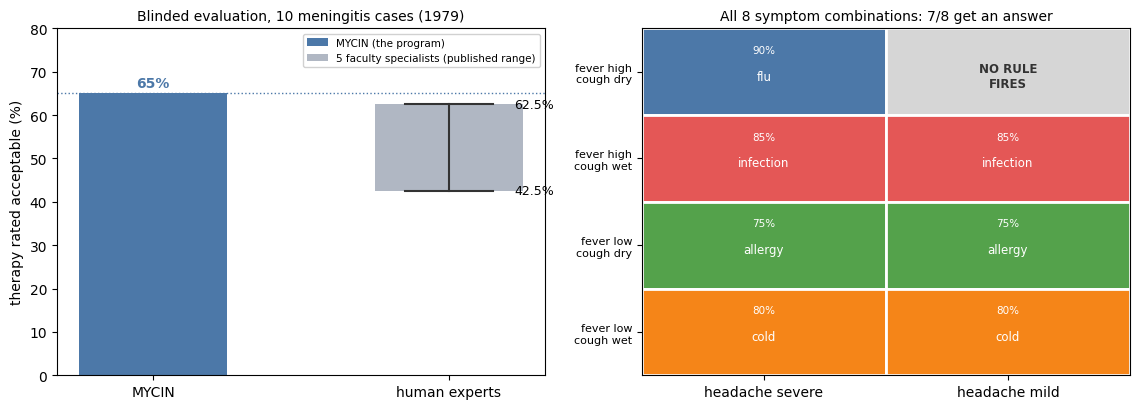

Combinations the rule base can answer : 7 of 8
Combinations that fall through entirely: 1 -> [('high', 'dry', 'mild')]

Full decision table:
  fever=high cough=dry headache=severe -> flu       (90%)
  fever=high cough=dry headache=mild   -> unknown   (0%)
  fever=high cough=wet headache=severe -> infection (85%)
  fever=high cough=wet headache=mild   -> infection (85%)
  fever=low  cough=dry headache=severe -> allergy   (75%)
  fever=low  cough=dry headache=mild   -> allergy   (75%)
  fever=low  cough=wet headache=severe -> cold      (80%)
  fever=low  cough=wet headache=mild   -> cold      (80%)


In [2]:
# 📊 FIGURE — the two claims of this lesson, drawn.
# LEFT panel  = the 1979 blinded evaluation described at the top of this notebook.
#               We plot ONLY the two figures that source states: MYCIN was rated
#               acceptable 65% of the time, and the five Stanford faculty specialists
#               fell somewhere between 42.5% and 62.5%. The specialists are therefore
#               drawn as a RANGE, not as five invented bars — we do not have their
#               individual scores, so we do not draw them.
# RIGHT panel = brittleness, computed from OUR OWN rule base above. We ask the engine
#               for a diagnosis on every one of the 2x2x2 = 8 possible symptom
#               combinations and colour each square by what came back.
import itertools
import matplotlib.pyplot as plt

# --- WHAT: run the engine over the complete symptom space -------------------
fevers, coughs, headaches = ['high', 'low'], ['dry', 'wet'], ['severe', 'mild']
grid_rows = list(itertools.product(fevers, coughs))      # 4 rows: fever x cough
grid_cols = headaches                                    # 2 columns: headache
outcomes = {}
for (fv, cg) in grid_rows:
    for hd in grid_cols:
        res = expert.forward_reasoning({'fever': fv, 'cough': cg, 'headache': hd})
        outcomes[(fv, cg, hd)] = (res['diagnosis'], res['confidence'])

covered = sum(1 for v in outcomes.values() if v[0] != 'unknown')
gaps = [k for k, v in outcomes.items() if v[0] == 'unknown']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2))

# --- LEFT: MYCIN vs the human specialists (Yu et al., JAMA 1979) ------------
ax1.bar([0], [65], width=0.5, color="#4C78A8", label="MYCIN (the program)")
# The five faculty specialists: a published RANGE, drawn as the band it is.
ax1.bar([1], [62.5 - 42.5], bottom=42.5, width=0.5, color="#B0B7C3",
        label="5 faculty specialists (published range)")
ax1.plot([1, 1], [42.5, 62.5], color="#333", lw=1.5)
for y in (42.5, 62.5):
    ax1.plot([0.85, 1.15], [y, y], color="#333", lw=1.5)
    ax1.text(1.22, y, f"{y}%", va="center", fontsize=9)
ax1.text(0, 66.5, "65%", ha="center", fontweight="bold", color="#4C78A8")
ax1.axhline(65, color="#4C78A8", ls=":", lw=1)
ax1.set_xticks([0, 1]); ax1.set_xticklabels(["MYCIN", "human experts"])
ax1.set_ylim(0, 80); ax1.set_ylabel("therapy rated acceptable (%)")
ax1.set_title("Blinded evaluation, 10 meningitis cases (1979)", fontsize=10)
ax1.legend(fontsize=7.5, loc="upper right", framealpha=0.9)

# --- RIGHT: which symptom combinations the rule base can answer -------------
palette = {'flu': "#4C78A8", 'infection': "#E45756", 'allergy': "#54A24B",
           'cold': "#F58518", 'unknown': "#D6D6D6"}
for r, (fv, cg) in enumerate(grid_rows):
    for c, hd in enumerate(grid_cols):
        dx, conf = outcomes[(fv, cg, hd)]
        ax2.add_patch(plt.Rectangle((c, r), 1, 1, facecolor=palette[dx],
                                    edgecolor="white", lw=2))
        label = dx if dx != 'unknown' else "NO RULE\nFIRES"
        ax2.text(c + 0.5, r + 0.55, label, ha="center", va="center", fontsize=8.5,
                 color="white" if dx != 'unknown' else "#333",
                 fontweight="bold" if dx == 'unknown' else "normal")
        if dx != 'unknown':
            ax2.text(c + 0.5, r + 0.25, f"{conf:.0%}", ha="center", va="center",
                     fontsize=7.5, color="white")
ax2.set_xlim(0, 2); ax2.set_ylim(0, len(grid_rows))
ax2.set_xticks([0.5, 1.5]); ax2.set_xticklabels(["headache severe", "headache mild"])
ax2.set_yticks([r + 0.5 for r in range(len(grid_rows))])
ax2.set_yticklabels([f"fever {fv}\ncough {cg}" for fv, cg in grid_rows], fontsize=8)
ax2.set_title(f"All 8 symptom combinations: {covered}/8 get an answer", fontsize=10)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# --- Print the numbers the caption below quotes, so they can never drift ----
print(f"Combinations the rule base can answer : {covered} of 8")
print(f"Combinations that fall through entirely: {len(gaps)} -> {gaps}")
print("\nFull decision table:")
for (fv, cg, hd), (dx, conf) in outcomes.items():
    print(f"  fever={fv:4s} cough={cg:3s} headache={hd:6s} -> {dx:9s} ({conf:.0%})")

### 👁️ Read the figure

**Left — being right was not enough.** The blue bar is MYCIN at **65%**; the grey
band is the whole span the five Stanford faculty specialists occupied, **42.5% to
62.5%**. The dotted line sits above the band's top: the program's score is outside
the human range, not inside it. That is the entire published comparison, and it is
why the deployment failure at the top of this notebook is a story about
infrastructure and liability rather than about accuracy.

**Right — where a rule system stops instead of degrading.** Each square is one of
the eight possible symptom combinations, coloured by what `forward_reasoning`
actually returned when we asked it. Seven squares carry a diagnosis and a
hand-written confidence. **One square is grey: fever high, cough dry, headache
mild — no rule fires and the engine returns nothing at all**, not a weaker guess.
Rule 1 needs all three symptoms and the mild headache breaks it; rule 2 needs a
wet cough. A patient who falls into that square gets silence.

**What this proves:** coverage of a rule base is not a property you can read off
the rules — you have to enumerate the space and look. Eight combinations already
have a hole. This is the wall XCON hit at 10,000 rules, visible at four.

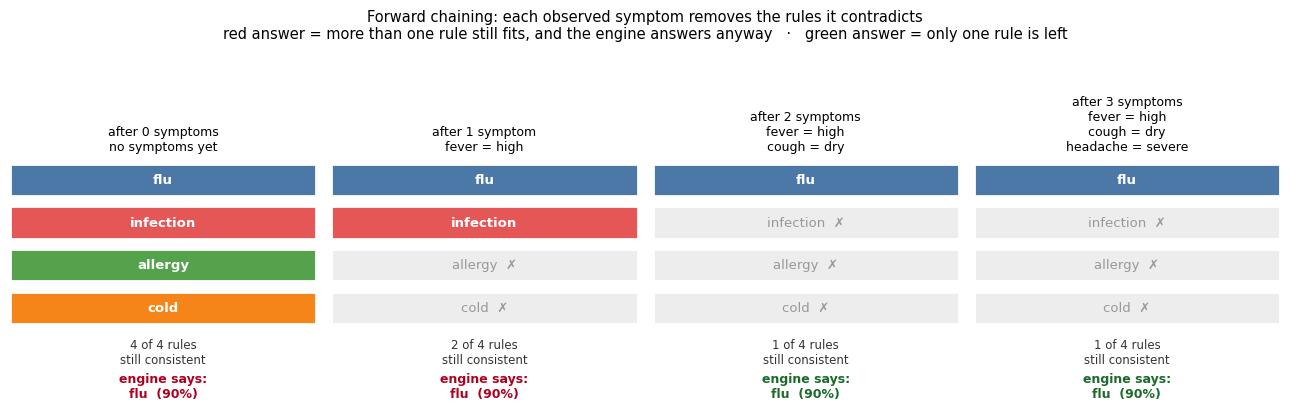

step | evidence so far                                   | rules live | engine's answer
  0  | (nothing observed)                                |     4      | flu (90%)
  1  | fever=high                                        |     2      | flu (90%)
  2  | fever=high, cough=dry                             |     1      | flu (90%)
  3  | fever=high, cough=dry, headache=severe            |     1      | flu (90%)

With no symptoms at all, every rule is vacuously consistent, so the engine still
returns its highest-confidence rule: flu (90%) on zero evidence.
After 2 symptoms only 1 rule remains, so the third symptom changes nothing: flu -> flu.


In [3]:
# 📊 FIGURE — forward chaining, one symptom at a time.
# WHAT: we ask the SAME `expert` object built above what it concludes after 0, 1, 2 and
#       3 symptoms have been observed, and draw the set of diagnoses still consistent
#       with the evidence at each step. Nothing new is invented: every chip is the
#       result of running `expert.forward_reasoning(...)` on a growing symptom dict.
# WHY: the printout above shows only the LAST step. Forward chaining is a process —
#      evidence arrives and the candidate set shrinks — and a single line of output
#      hides the whole movement.
import matplotlib.pyplot as plt

# The order a clinician would actually collect these in.
observation_order = [("fever", "high"), ("cough", "dry"), ("headache", "severe")]
DIAGNOSES = ["flu", "infection", "allergy", "cold"]
COLOUR = {"flu": "#4C78A8", "infection": "#E45756", "allergy": "#54A24B", "cold": "#F58518"}

# --- WHAT: replay the engine after each new symptom -------------------------
steps = []
evidence = {}
for k in range(len(observation_order) + 1):
    if k > 0:
        key, val = observation_order[k - 1]
        evidence[key] = val
    # A rule is still "live" if nothing observed so far contradicts it — which is
    # exactly the test forward_reasoning applies before it fires a rule.
    live = [r for r in expert.rules
            if all(evidence.get(c) == v for c, v in r["conditions"].items() if c in evidence)]
    steps.append((dict(evidence), live, expert.forward_reasoning(evidence)))

fig, axes = plt.subplots(1, len(steps), figsize=(13.0, 3.9))
for ax, (ev, live, res) in zip(axes, steps):
    live_dx = {r["diagnosis"]: r["confidence"] for r in live}
    for i, dx in enumerate(DIAGNOSES):
        y = len(DIAGNOSES) - 1 - i
        alive = dx in live_dx
        ax.add_patch(plt.Rectangle((0, y + 0.12), 1, 0.76,
                                   facecolor=COLOUR[dx] if alive else "#EDEDED",
                                   edgecolor="white", lw=2))
        ax.text(0.5, y + 0.5, dx if alive else f"{dx}  ✗", ha="center", va="center",
                fontsize=9.5, color="white" if alive else "#999",
                fontweight="bold" if alive else "normal")
    header = "no symptoms yet" if not ev else "\n".join(f"{k} = {v}" for k, v in ev.items())
    ax.set_title(f"after {len(ev)} symptom{'' if len(ev) == 1 else 's'}\n{header}",
                 fontsize=9)
    ax.text(0.5, -0.55, f"{len(live)} of 4 rules\nstill consistent",
            ha="center", va="center", fontsize=8.5, color="#333")
    ax.text(0.5, -1.35, f"engine says:\n{res['diagnosis']}  ({res['confidence']:.0%})",
            ha="center", va="center", fontsize=9, fontweight="bold",
            color="#B00020" if len(live) > 1 else "#1A6B2A")
    ax.set_xlim(0, 1); ax.set_ylim(-1.85, len(DIAGNOSES))
    ax.set_axis_off()

fig.suptitle("Forward chaining: each observed symptom removes the rules it contradicts\n"
             "red answer = more than one rule still fits, and the engine answers anyway   ·   "
             "green answer = only one rule is left",
             fontsize=10.5, y=1.06)
plt.tight_layout()
plt.show()

# --- Print the same sequence, so the caption can never drift from the run ----
print("step | evidence so far                                   | rules live | engine's answer")
for ev, live, res in steps:
    ev_s = ", ".join(f"{k}={v}" for k, v in ev.items()) or "(nothing observed)"
    print(f"  {len(ev)}  | {ev_s:49s} |     {len(live)}      | "
          f"{res['diagnosis']} ({res['confidence']:.0%})")
print("\nWith no symptoms at all, every rule is vacuously consistent, so the engine still")
print(f"returns its highest-confidence rule: {steps[0][2]['diagnosis']} "
      f"({steps[0][2]['confidence']:.0%}) on zero evidence.")
print(f"After 2 symptoms only {len(steps[2][1])} rule remains, so the third symptom "
      f"changes nothing: {steps[2][2]['diagnosis']} -> {steps[3][2]['diagnosis']}.")


### 👁️ Read the figure

Four frames of the *same* engine, differing only in how much has been observed. The
chips are the four diagnoses; a coloured chip means at least one rule concluding it
is still consistent with the evidence, a grey chip with ✗ means every such rule has
been contradicted.

- **Frame 1 → 2: `fever = high` eliminates half the rule base.** `allergy` and `cold`
  both require `fever = low`, so both go grey the moment the thermometer is read.
  Four candidates become two.
- **Frame 2 → 3: `cough = dry` finishes the job.** `infection` needs a wet cough.
  One rule is left and the diagnosis is settled — after **two** symptoms.
- **Frame 3 → 4 is deliberately identical.** The third symptom, `headache = severe`,
  removes nothing, because there was nothing left to remove. In a clinic that is the
  useful fact: the third question was not worth asking, and knowing *which* question
  still discriminates is the job of backward chaining, in the table below.

**The red answers in frames 1 and 2 are the finding.** With **no symptoms at all**
the engine still reports `flu` at **90%**. Look at `forward_reasoning`: it tests
`if key in symptoms`, so a rule whose conditions have not been observed is not
contradicted, it is *vacuously satisfied* — all four rules "match", and the engine
returns the one with the highest hand-written confidence. **The system is at its
most confident-sounding when it knows nothing**, and no part of its output says so.
The confidence number is attached to the rule, never to the evidence.

**What this proves:** forward chaining is a process of elimination, and the number
printed at the end tells you what was concluded but not how much of the conclusion
was earned. The count `n of 4 rules still consistent` is the missing column — and
turning that count into a defensible number is exactly what Bayes' theorem, two
notebooks from now, is for. (Contrast this with the eight-square panel above: that
one asks which inputs the rule base can answer *at all*; this one asks how the
answer narrows as one patient is examined.)

## 📊 Same knowledge base, two directions — read the two outputs together

The cell ran one inference engine twice, changing exactly one thing: **which end
of the rule it starts from.**

| direction | what you give it | what it gives back | printed result |
|---|---|---|---|
| **Forward** (data-driven) | the symptoms | the conclusion they support | `flu`, confidence **90%** |
| **Backward** (goal-driven) | the hypothesis `flu` | the evidence that would establish it | `{fever: high, cough: dry, headache: severe}` |

**The conclusion these two runs support:** the same rules serve two different
jobs. Forward chaining is what you want when the data arrives first and you do not
know what you are looking for — monitoring, alarms, diagnosis from a full workup.
Backward chaining is what you want when you have a hypothesis and a limited budget
for tests, because it tells you *which question to ask next*. A doctor with one
test left needs the second engine, not the first.

**What they do not support:** any claim about accuracy. Both runs used one patient
and rules written by hand. Nothing here was measured against an outcome — which is
precisely the gap Bayes' theorem, two notebooks from now, is built to close.


## 💬 Discuss

The system above diagnosed `flu` at **90% confidence** by forward reasoning, then
backward reasoning listed exactly which symptoms would be needed to reach that
same conclusion.

1. Where does 0.90 come from? Nobody measured it — it is a number the rule author
   typed. MYCIN had the same problem and invented "certainty factors" to manage
   it, a scheme later criticised for not being probabilities at all. **Would you
   show that 90% to a patient?** If not, what would you show instead?
2. MYCIN beat five specialists in a blinded trial and was never used. List what
   *else*, beyond accuracy, a clinical tool needs before deployment — then check
   your list against the diagnosis system above and mark what it lacks.
3. Rule systems did not disappear; they moved. A 2026 language-model agent is
   given a **tool schema** — a declared list of actions with typed arguments and
   preconditions — and an explicit failure path. Compare that schema to the
   knowledge base above: what is genuinely new, and what is XCON with better
   syntax? Where would the 10,000-rule maintenance wall reappear?


## ⚠️ Where this breaks

- **The knowledge-acquisition bottleneck is the whole story.** Every rule is typed
  by a human expert, and experts are expensive, disagree with each other, and
  cannot articulate much of what they know. This is the wall XCON hit at 10,000+
  rules and it is why the field turned to learning from data.
- **Rules interact combinatorially.** With *n* rules there are far more than *n*
  ways they can fire in sequence. Adding rule 501 can silently change what rules
  1-500 conclude, and there is no test suite short enough to catch it.
- **Exact matching means brittle behaviour.** Our engine needs the symptoms to
  match a rule's conditions. The figure above enumerates all eight symptom
  combinations: a patient with high fever, a *dry* cough and a *mild*
  headache falls through every rule and gets nothing — not a lower-confidence
  answer, *nothing*. Rule systems do not degrade gracefully; they stop.
- **The confidence numbers are decoration.** 0.90 was written by hand and is not
  calibrated against any outcome data. Two rules firing does not multiply into a
  meaningful joint confidence. **Use instead:** Bayes' theorem with measured base
  rates — the next notebook — when you need a number you can defend.
- **It cannot learn.** Every correction is a code change by a knowledge engineer.
  A system seeing a thousand cases a week learns nothing from any of them.
- **When a rule system is still the right answer:** when the rules are *given* —
  by law, regulation, tax code, safety standard or clinical protocol — rather than
  discovered. Then hand-written rules are not a weak substitute for a model; they
  are the correct implementation, because the requirement is to follow the rule
  exactly and be able to prove that you did.


## 🔭 State of the field (2026)

Nobody ships a 10,000-rule expert system in 2026 — but the skeleton of one is everywhere, and the
third Discuss question above points straight at it. A modern tool-using assistant is handed a **tool
schema**: a declared list of actions with typed arguments, preconditions and an explicit failure path.
That is a knowledge base of what may be done, written by engineers, exactly as MYCIN's rules were.
Tool schemas now have a de-facto standard — the Model Context Protocol turned per-vendor plugins into
a shared client/server ecosystem, and the survey that maps it also maps the attack surface it created
(Hou et al., 2025). XCON's maintenance wall came back in a new form as a *security* wall: because a
learned model now chooses which tool to call, the durable defence is not a better prompt but a
declared privilege policy stating which calls are permitted at all (Shi et al., 2025) — a rule engine
placed in front of a learned one.

Build the inference engine above by hand first. Forward and backward chaining, conflict resolution
and the knowledge-acquisition bottleneck are the concepts that make a 2026 tool schema readable
instead of magical — and hand-written rules remain the right answer, not a weak substitute, whenever
the rules are *given* to you by law, protocol or safety standard.

*Orientation only — the assessed content of this lesson is everything above this box.*

## 📚 References

1. Shortliffe, E. H., & Buchanan, B. G. (1975). *A Model of Inexact Reasoning in Medicine* (MYCIN). Mathematical Biosciences, 23(3–4), 351–379.
2. Buchanan, B. G., & Shortliffe, E. H. (1984). *Rule-Based Expert Systems: The MYCIN Experiments of the Stanford Heuristic Programming Project*. Addison-Wesley.
3. d'Avila Garcez, A., & Lamb, L. C. (2020). *Neurosymbolic AI: The 3rd Wave*. Artificial Intelligence Review (2023). <https://arxiv.org/abs/2012.05876>
4. Hou, X., Zhao, Y., Wang, S., et al. (2025). *Model Context Protocol (MCP): Landscape, Security Threats, and Future Research Directions*. arXiv. <https://arxiv.org/abs/2503.23278>
5. Shi, T., He, J., Wang, Z., et al. (2025). *Progent: Securing AI Agents with Privilege Control*. arXiv. <https://arxiv.org/abs/2504.11703>